# HCIA-AI Study Assistant: Indexing & RAG Pipeline

This notebook **builds everything the app needs**:

| Part | What it does | Output |
|---|---|---|
| 1. EDA | Checks text extraction and duplicates in the lecture PDFs | Decisions table + chart |
| 2. Question bank | Converts the Word question bank to structured data | `question_bank.json` |
| 3. Pages → chunks | One slide = one chunk, cleaned, empty + duplicate pages removed | `pages.json` |
| 4. Index | Dense embeddings + ChromaDB with metadata (lecture, page) | `rag_db/` |
| 5. Retrieval | Hybrid search (dense + TF-IDF) | test results |
| 6. Generation | Grounded explanation with slide citations | test answers |
| 7. Quiz | MCQs generated from the retrieved slides (JSON), validated and graded | test quiz |

The app (`app.py`) only **reads** `rag_db/` and `question_bank.json`.

**Project folder layout**
```
RAG-Project/
├── Study_Assistant_Pipeline.ipynb
├── app.py                  ← Streamlit app
├── assets/                 ← style.css (theme) + study_buddy.webp (character)
├── .streamlit/config.toml  ← light theme, file watcher off
├── .env                    ← OPENAI_API_KEY=...  (not on GitHub)
├── question_bank.docx
├── question_bank.json      ← generated by Section 2
├── pages.json              ← generated by Section 3
├── rag_db/                 ← generated by Section 4
├── agentic_chunks.json     ← output of the Appendix experiment
├── lectures/               ← PDFs we index
└── excluded/               ← PDFs we checked and decided NOT to index
```

## 0. Setup

In [23]:
# Run once if a library is missing
# %pip install pypdf python-docx langchain-openai python-dotenv sentence-transformers chromadb scikit-learn pandas matplotlib streamlit

In [24]:
import os
import re
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
from docx import Document
from dotenv import load_dotenv
from pypdf import PdfReader
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
# ---------- Paths (relative → works on any computer after git clone) ----------
BASE_DIR = Path.cwd()          # the folder this notebook is in

LECTURES_DIR = BASE_DIR / "lectures"
EXCLUDED_DIR = BASE_DIR / "excluded"
BANK_DOCX    = BASE_DIR / "question_bank.docx"
BANK_JSON    = BASE_DIR / "question_bank.json"
PAGES_JSON   = BASE_DIR / "pages.json"
DB_PATH      = BASE_DIR / "rag_db"
ENV_PATH     = BASE_DIR / ".env"

# ---------- Settings (must match app.py) ----------
COLLECTION_NAME = "lectures"
MODEL_NAME      = "BAAI/bge-small-en-v1.5"
LLM_NAME        = "gpt-4o-mini"
MIN_CHARS       = 30           # pages shorter than this are treated as empty

# ---------- API key ----------
load_dotenv(ENV_PATH, override=True)
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(f"OPENAI_API_KEY not found in {ENV_PATH}")

for name, path in [("lectures/", LECTURES_DIR), ("excluded/", EXCLUDED_DIR),
                   ("question bank", BANK_DOCX), (".env", ENV_PATH)]:
    print(f"{name:14} exists: {path.exists()}")

print("\nPDFs to index:", len(list(LECTURES_DIR.glob("*.pdf"))))
print("PDFs excluded:", len(list(EXCLUDED_DIR.glob("*.pdf"))))

lectures/      exists: True
excluded/      exists: True
question bank  exists: True
.env           exists: True

PDFs to index: 22
PDFs excluded: 2


## 1. EDA: can we read the lectures?

Before indexing, we check that `pypdf` actually extracts text from every file.
A slide that is an image returns empty text, and the model would silently know nothing about it.

We check **both** folders, so the table also documents *why* the excluded files were excluded.

In [26]:
def get_pages_text(pdf_path):
    reader = PdfReader(pdf_path)
    pages_text = []
    for page in reader.pages:
        text = page.extract_text() or ""
        pages_text.append(text.strip())
    return pages_text


all_pdfs = []
for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "indexed"))
for pdf_path in sorted(EXCLUDED_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "excluded"))

rows = []
for pdf_path, status in all_pdfs:
    pages_text = get_pages_text(pdf_path)
    lengths = [len(t) for t in pages_text]
    empty_count = sum(1 for n in lengths if n < MIN_CHARS)

    rows.append({
        "file": pdf_path.stem,
        "status": status,
        "pages": len(pages_text),
        "avg_chars": round(sum(lengths) / len(lengths)),
        "empty_pages": empty_count,
        "empty_%": round(empty_count / len(pages_text) * 100),
    })

eda_df = pd.DataFrame(rows).sort_values("empty_%", ascending=False)
eda_df

,file,status,pages,avg_chars,empty_pages,empty_%
23,Linear_Regression-1 2,excluded,79,0,79,100
3,decision tree & ensemble learning & random forest,indexed,55,245,22,40
19,NLP - Text preprocessing,indexed,64,254,25,39
12,Hierarchical Clustering,indexed,27,94,8,30
4,decision tree & ensemble learning,indexed,107,294,29,27
15,K-means,indexed,37,142,8,22
21,Word Embedding,indexed,36,496,7,19
13,Imbalanced_Data,indexed,19,476,1,5
7,Feature Selection in Machine Learning,indexed,37,642,0,0
6,Exploratory Data Analysis_Nancy Ahmed (2),indexed,45,382,0,0


**Chart:** percentage of pages with no extractable text, per file.
- **X-axis:** % of empty pages
- **Y-axis:** file name
- **Look for:** long bars = content we cannot read as text (images / screenshots).
- **Careful:** an empty page is not always lost content. It can be a title slide or a diagram.
  We opened the flagged files to check (see the decisions table below).

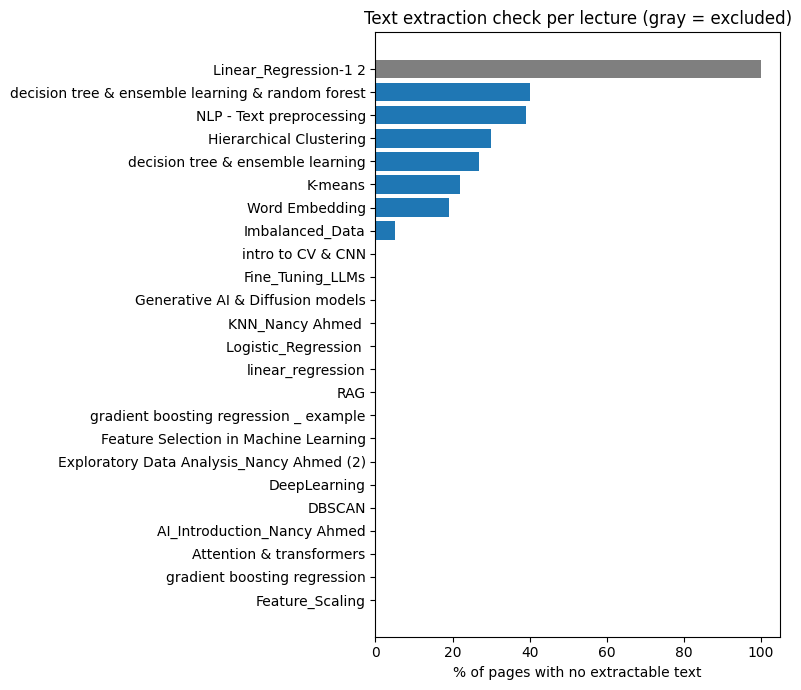

In [27]:
plot_df = eda_df.sort_values("empty_%")
colors = ["tab:gray" if s == "excluded" else "tab:blue" for s in plot_df["status"]]

plt.figure(figsize=(8, 7))
plt.barh(plot_df["file"], plot_df["empty_%"], color=colors)
plt.xlabel("% of pages with no extractable text")
plt.title("Text extraction check per lecture (gray = excluded)")
plt.tight_layout()
plt.show()

### Duplicate check
Two files had the same page count and average length, and two others shared the same empty-page pattern.
Duplicates hurt RAG: with `top_k=3`, two of the three results could be the same slide, and the quiz would repeat questions.

In [28]:
a = get_pages_text(LECTURES_DIR / "gradient boosting regression.pdf")
b = get_pages_text(EXCLUDED_DIR / "gradient boosting regression _ example.pdf")
print("Gradient boosting files identical:", a == b)

small = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning & random forest.pdf")
big = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning.pdf")

big_set = set(big)
non_empty_small = [page for page in small if page]
found = 0
for page in non_empty_small:
    if page in big_set:
        found += 1

print(f"{found} / {len(non_empty_small)} pages of the small decision tree file exist in the big file")

Gradient boosting files identical: True
32 / 43 pages of the small decision tree file exist in the big file


### Decisions from the EDA

| Finding | Decision | Why |
|---|---|---|
| `gradient boosting regression _ example` is 100% identical to `gradient boosting regression` | Moved to `excluded/` | Exact duplicate |
| `Linear_Regression-1 2` has 0 extractable characters (79 pages) | Moved to `excluded/` | Opened it: 60+ pages are graphs used for visual explanation, no real text content. The text version is `linear_regression` |
| Small decision tree file: 32 / 43 pages exist in the big file | Keep **both**, remove duplicate **pages** automatically (Section 3) | The small file has 11 unique pages |
| Hierarchical Clustering, K-means, NLP, Word Embedding have many empty pages | Index the text now; screenshots are a **known limitation** | Opened Hierarchical: most empty pages are screenshots with text inside. Possible fix later: a vision LLM to transcribe them |
| All other files | Index normally | Text extracts correctly |

## 2. Question bank → structured data

The bank is a Word file: section headings (style `Heading 1`), then questions like
`2. [Multiple-Choice — select all that apply] Which ...`, each followed by options `A.` to `D.`.

We convert it to a list of dicts (`question_bank.json`) so the notebook and the app can load it quickly.

**Important:** the bank has **no answers**. We use it only for:
- **Style examples (few-shot)** when generating new quiz questions from the lectures (Section 7.1)

(Future work: a "practice from bank" mode, where our RAG answers a bank question from the lectures and shows the source slide.)

In [29]:
doc = Document(BANK_DOCX)

questions = []
current_section = None
current_question = None

for paragraph in doc.paragraphs:
    text = paragraph.text.strip()
    if not text:
        continue

    # 1) Section title, e.g. "1. AI Fundamentals & Applications"
    if paragraph.style.name == "Heading 1":
        current_section = re.sub(r"^\d+\.\s*", "", text)
        continue

    # 2) Question line, e.g. "2. [Multiple-Choice — select all that apply] Which of..."
    question_match = re.match(r"^(\d+)\.\s*\[(.+?)\]\s*(.+)$", text)
    if question_match:
        number = int(question_match.group(1))
        type_text = question_match.group(2)
        question_text = question_match.group(3)

        if type_text.startswith("Multiple"):
            q_type = "multiple"
        else:
            q_type = "single"

        current_question = {
            "id": f"bank_{number}",
            "section": current_section,
            "type": q_type,
            "question": question_text,
            "options": {}
        }
        questions.append(current_question)
        continue

    # 3) Option line, e.g. "A. Predictive maintenance of equipment"
    option_match = re.match(r"^([A-F])\.\s*(.+)$", text)
    if option_match and current_question is not None:
        letter = option_match.group(1)
        current_question["options"][letter] = option_match.group(2)


# ---------- Sanity checks (expected: 130 questions, 100 single / 30 multiple, all with 4 options) ----------
print("Total questions:", len(questions))
print("Per type:", Counter(q["type"] for q in questions))
print("Options per question:", Counter(len(q["options"]) for q in questions))
print("\nPer section:")
for section, count in Counter(q["section"] for q in questions).items():
    print(f"  {count:3}  {section}")

with open(BANK_JSON, "w", encoding="utf-8") as f:
    json.dump(questions, f, ensure_ascii=False, indent=2)
print("\nSaved →", BANK_JSON.name)

Total questions: 130
Per type: Counter({'single': 100, 'multiple': 30})
Options per question: Counter({4: 130})

Per section:
   13  AI Fundamentals & Applications
   12  Machine Learning Basics
   15  Neural Networks & Activation Functions
   13  Training, Optimization & Regularization
   12  CNNs & Computer Vision
   12  NLP, Transformer & Attention
   14  Frameworks & Tools
   15  Large Models & Fine-Tuning
   12  Parallel Training
   12  Data Preprocessing & Evaluation

Saved → question_bank.json


## 3. Pages → chunks (page-based chunking)

**Decision: one slide = one chunk.**

| | Agentic chunking (first experiment, see Appendix) | Page-based (chosen) |
|---|---|---|
| Idea | LLM decides which paragraphs belong together | Each slide is one chunk |
| Page number for citations | Lost (pages were joined before splitting) | Kept automatically |
| Cost / time for 22 PDFs | One API call per paragraph | Zero |
| Fits our data? | Better for long continuous text | Slides already hold ~one idea each |

For every page we:
1. **Clean** it (`fix_spaced_letters`: `Q U A N T I Z E D` → `QUANTIZED`)
2. **Skip** it if it is empty (< `MIN_CHARS`)
3. **Skip** it if the exact same text was already added (duplicate pages across files)
4. **Keep** its metadata: lecture name + page number

In [30]:
def fix_spaced_letters(text):
    # 3+ single characters separated by single spaces → join them
    pattern = r'\b(?:[A-Za-z0-9&\-] ){2,}[A-Za-z0-9&\-]\b'
    text = re.sub(pattern, lambda m: m.group(0).replace(" ", ""), text)

    # collapse repeated spaces (keep newlines)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def clean_lecture_name(file_stem):
    # "KNN_Nancy Ahmed " → "KNN" ,  "Exploratory Data Analysis_Nancy Ahmed (2)" → "Exploratory Data Analysis"
    name = file_stem.replace("_Nancy Ahmed", "")
    name = name.replace("(2)", "")
    name = name.replace("_", " ")
    name = re.sub(r"\s+", " ", name)
    return name.strip()


print(clean_lecture_name("KNN_Nancy Ahmed "))
print(clean_lecture_name("Exploratory Data Analysis_Nancy Ahmed (2)"))

KNN
Exploratory Data Analysis


In [31]:
pages = []            # the chunks we will index
seen_texts = set()    # cleaned text of every page already added → catches duplicates
report_rows = []      # what happened to each file

for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    lecture = clean_lecture_name(pdf_path.stem)
    pages_text = get_pages_text(pdf_path)

    kept = 0
    skipped_empty = 0
    skipped_duplicate = 0

    for page_number, raw_text in enumerate(pages_text, start=1):
        text = fix_spaced_letters(raw_text)

        if len(text) < MIN_CHARS:
            skipped_empty += 1
            continue

        if text in seen_texts:
            skipped_duplicate += 1
            continue

        seen_texts.add(text)
        pages.append({
            "id": f"{lecture}_p{page_number}",
            "lecture": lecture,
            "page": page_number,
            "source": pdf_path.name,
            "text": text,
        })
        kept += 1

    report_rows.append({
        "lecture": lecture,
        "pages": len(pages_text),
        "kept": kept,
        "skipped_empty": skipped_empty,
        "skipped_duplicate": skipped_duplicate,
    })

report_df = pd.DataFrame(report_rows)
print("Total chunks:", len(pages))
print("Unique ids:", len(set(p["id"] for p in pages)) == len(pages))
report_df

Total chunks: 887
Unique ids: True


,lecture,pages,kept,skipped_empty,skipped_duplicate
0,AI Introduction,45,45,0,0
1,Attention & transformers,47,47,0,0
2,DBSCAN,14,14,0,0
3,decision tree & ensemble learning & random forest,55,33,22,0
4,decision tree & ensemble learning,107,56,29,22
5,DeepLearning,87,87,0,0
6,Exploratory Data Analysis,45,43,0,2
7,Feature Selection in Machine Learning,37,37,0,0
8,Feature Scaling,17,17,0,0
9,Fine Tuning LLMs,58,58,0,0


**What to expect:** most files have `skipped_duplicate = 0`.
The small decision tree file comes first alphabetically, so it is added first and keeps all its non-empty pages.
The **big** one shows **22** skipped duplicates, not 32: the two files share 32 pages,
but 10 of them are shorter than `MIN_CHARS` after cleaning, so they are counted as `skipped_empty` before the duplicate check.

In [32]:
with open(PAGES_JSON, "w", encoding="utf-8") as f:
    json.dump(pages, f, ensure_ascii=False, indent=2)
print("Saved →", PAGES_JSON.name)

print("\nExample chunk:")
print(pages[10]["id"])
print(pages[10]["text"][:300])

Saved → pages.json

Example chunk:
AI Introduction_p11
11 Copyright @ 2026 NTI 
THE ONLY TYPE THAT EXISTS TODAY
AI designed to 
perform one specific 
task very well.
Even ChatGPT — despite 
doing many language tasks —
is still Narrow AI: it is 
specialized and lacks human-
level general intelligence 
across all domains.
EXAMPLES
ChatGPT Siri Face 
Recog


## 4. Embeddings + ChromaDB

`bge-small-en-v1.5`: max 512 tokens, 384 dimensions, English only.

**Lecture name inside the embedded text:** many slides never mention their topic
(e.g. *"Step 2: assign each point to the nearest centroid"* never says "K-means").
So we embed `"[K-means]\n" + text`. This way a question about K-means can still find that slide,
for both dense and TF-IDF search.

In [33]:
dense_model = SentenceTransformer(MODEL_NAME)
print("Max tokens:", dense_model.max_seq_length)
print("Embedding dim:", dense_model.get_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Basmala\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Basmala\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Max tokens: 512
Embedding dim: 384


In [34]:
documents = []
for p in pages:
    documents.append(f"[{p['lecture']}]\n{p['text']}")

# Check how many chunks exceed the model limit (-2 for [CLS] and [SEP])
token_counts = [len(dense_model.tokenizer.tokenize(d)) for d in documents]
limit = dense_model.max_seq_length - 2
too_long = [pages[i]["id"] for i, n in enumerate(token_counts) if n > limit]

print("Largest chunk (tokens):", max(token_counts))
print("Average chunk (tokens):", round(sum(token_counts) / len(token_counts)))
print("Chunks that will be truncated:", len(too_long), too_long[:10])

Largest chunk (tokens): 370
Average chunk (tokens): 96
Chunks that will be truncated: 0 []


In [35]:
dense_vectors = dense_model.encode(
    documents,
    normalize_embeddings=True,
    show_progress_bar=True
)
print("Dense shape:", dense_vectors.shape)

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Dense shape: (887, 384)


In [36]:
client = chromadb.PersistentClient(path=str(DB_PATH))

try:
    client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=None,
    metadata={"hnsw:space": "cosine"}
)

chunk_ids = []
chunk_metadatas = []
for p in pages:
    chunk_ids.append(p["id"])
    chunk_metadatas.append({
        "lecture": p["lecture"],
        "page": p["page"],
        "source": p["source"],
    })

collection.add(
    ids=chunk_ids,
    documents=documents,
    embeddings=dense_vectors.tolist(),
    metadatas=chunk_metadatas
)
print("Chunks stored:", collection.count())

Chunks stored: 887


In [37]:
# Metadata filter test: every chunk keeps its lecture name, so we can get all slides of ONE lecture
# (not used by the quiz, which uses the retrieved slides; kept for future work, e.g. a quiz on a whole lecture)
knn_slides = collection.get(where={"lecture": "KNN"}, include=["metadatas"])
print("KNN slides in the DB:", len(knn_slides["ids"]))
print(knn_slides["ids"][:5])

KNN slides in the DB: 64
['KNN_p2', 'KNN_p3', 'KNN_p4', 'KNN_p5', 'KNN_p6']


## 5. Load from ChromaDB + Hybrid Search
These are the same steps `app.py` runs once when it starts (`load_resources`, cached with `@st.cache_resource`).
TF-IDF is **fit on the stored chunks only**, and the query is only **transformed** (no fit), same as train/test.

In [38]:
client = chromadb.PersistentClient(path=str(DB_PATH))
collection = client.get_collection(name=COLLECTION_NAME, embedding_function=None)

stored = collection.get(include=["documents", "metadatas"])
stored_ids = stored["ids"]
stored_docs = stored["documents"]
stored_metas = stored["metadatas"]
print("Loaded chunks:", len(stored_docs))

tfidf = TfidfVectorizer(lowercase=True, stop_words="english")
sparse_vectors = tfidf.fit_transform(stored_docs)
print("Sparse shape:", sparse_vectors.shape)

Loaded chunks: 887
Sparse shape: (887, 4917)


In [39]:
def embed_query(query):
    query = query.strip()
    if not query:
        raise ValueError("Query is empty!")

    # Dense: same model + same normalization as the chunks
    query_dense = dense_model.encode([query], normalize_embeddings=True)

    # Sparse: same TF-IDF, transform only (no fit!)
    query_sparse = tfidf.transform([query])

    return query_dense, query_sparse


def min_max(scores):
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())


def hybrid_search(query, alpha=0.5, top_k=3):
    query_dense, query_sparse = embed_query(query)

    # 1) Dense scores from ChromaDB (cosine distance → similarity)
    results = collection.query(
        query_embeddings=query_dense.tolist(),
        n_results=collection.count(),
        include=["distances"]
    )
    dense_by_id = {}
    for chunk_id, distance in zip(results["ids"][0], results["distances"][0]):
        dense_by_id[chunk_id] = 1 - distance
    dense_scores = np.array([dense_by_id[chunk_id] for chunk_id in stored_ids])

    # 2) Sparse scores from TF-IDF
    sparse_scores = (sparse_vectors @ query_sparse.T).toarray().ravel()

    # 3) Normalize + combine
    hybrid_scores = alpha * min_max(dense_scores) + (1 - alpha) * min_max(sparse_scores)

    # 4) Top results
    top_positions = np.argsort(hybrid_scores)[::-1][:top_k]

    top_chunks = []
    for pos in top_positions:
        top_chunks.append({
            "id": stored_ids[pos],
            "lecture": stored_metas[pos]["lecture"],
            "page": stored_metas[pos]["page"],
            "text": stored_docs[pos],
            "score": hybrid_scores[pos],
        })
    return top_chunks

In [40]:
test_queries = [
    "What is QLoRA?",
    "How does K-means choose the centroids?",
    "What is the difference between bagging and boosting?",
    "Why do we scale features before KNN?",
]

for query in test_queries:
    print("Q:", query)
    for r in hybrid_search(query, alpha=0.5, top_k=3):
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")
    print()

Q: What is QLoRA?
   1.00 | Fine Tuning LLMs p.15
   0.75 | Fine Tuning LLMs p.17
   0.56 | Fine Tuning LLMs p.23

Q: How does K-means choose the centroids?
   0.96 | K-means p.21
   0.92 | K-means p.11
   0.92 | K-means p.13

Q: What is the difference between bagging and boosting?
   0.91 | decision tree & ensemble learning p.106
   0.89 | decision tree & ensemble learning p.107
   0.89 | decision tree & ensemble learning & random forest p.29

Q: Why do we scale features before KNN?
   0.89 | KNN p.53
   0.88 | Feature Scaling p.15
   0.84 | KNN p.64



**What to look for:** the top result should come from the lecture you expect.
If a question goes to the wrong lecture, note it: these are exactly the cases the evaluation (Hit@3 for different alpha values) will measure.

## 6. Generation (Explain mode)
The LLM explains **only** from the retrieved slides (grounding) and cites them as `[Lecture p.X]`.

In [41]:
gen_llm = ChatOpenAI(model=LLM_NAME, temperature=0)

In [42]:
def build_prompt(query, retrieved_chunks):
    context_parts = []
    for c in retrieved_chunks:
        context_parts.append(f"[{c['lecture']} p.{c['page']}]\n{c['text']}")
    context = "\n\n---\n\n".join(context_parts)

    return f"""You are a helpful tutor helping a student study an AI / Machine Learning course.
The context below contains the lecture slides most relevant to the question.

How to answer:
1. Find every sentence in the context related to the question, even if it uses different words.
2. Explain clearly using only those sentences. Do not add outside knowledge.
3. If the slides cover the question only partly, explain what they cover,
   then add one line saying what they do not cover.
4. Reply "I don't know based on the lectures." ONLY if nothing in the context is related.
5. Cite the slides you used, like [K-means p.12].

Context:
{context}

Question: {query}

Answer:"""


def rag_answer(query, alpha=0.5, top_k=3):
    retrieved = hybrid_search(query, alpha=alpha, top_k=top_k)

    print("Retrieved:")
    for r in retrieved:
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")

    prompt = build_prompt(query, retrieved)
    response = gen_llm.invoke(prompt)
    return response.content, retrieved

In [43]:
answer, used_chunks = rag_answer("How does K-means choose the centroids?")
print("\n" + answer)

print("\n" + "=" * 60 + "\n")

answer, used_chunks = rag_answer("Who won the 2022 World Cup?")
print("\n" + answer)

Retrieved:
   0.96 | K-means p.21
   0.92 | K-means p.11
   0.92 | K-means p.13

K-means chooses the centroids by selecting different random starting points to achieve the best possible result. Additionally, it can use the K-means++ method, which selects the first centroid randomly and then chooses the remaining centroids based on their distance from the first one, giving higher probability to points that are farther away [K-means p.21]. 

The slides do not cover the specific mathematical methods or algorithms used to determine the initial centroids beyond mentioning random selection and K-means++.


Retrieved:
   0.69 | K-means p.25
   0.66 | AI Introduction p.2
   0.55 | Imbalanced Data p.1

I don't know based on the lectures.


`rag_answer` now also returns `retrieved`: these are the slides of "the part you asked about".
In the app they are saved in `st.session_state`, and the **Quiz me on this** button generates questions from them (Section 7).

## 7. Quiz generation ("Quiz me on this")
The quiz questions are generated **only from the retrieved slides** (the same chunks used in the explanation).
The question bank is used **only for style** (few-shot examples), never as content,
because some bank sections (e.g. Parallel Training) are not covered by our lectures.

| Step | Function | Why |
|---|---|---|
| 7.1 | `get_style_examples` | 3 closest bank questions → the LLM copies the Huawei exam **style** |
| 7.2 | `build_quiz_prompt` | Slides = the only allowed content, answer format = JSON |
| 7.3 | `check_question` | The LLM output is not guaranteed → drop bad questions instead of crashing the demo |
| 7.4 | `generate_quiz` | Prompt → LLM → `json.loads` → keep valid questions only |
| 7.5 | `grade_answer` | Single and multiple choice, all-or-nothing like the Huawei exam |

### 7.1 Style examples (few-shot)
We embed the 130 bank questions **once** with the same `dense_model`,
then pick the 3 closest to the student's topic (vectors are normalized → dot product = cosine similarity).
Only dense similarity here: we want questions with a similar **meaning**, not the same words.

In [44]:
# ---------- Load the bank + embed its questions once ----------
with open(BANK_JSON, encoding="utf-8") as f:
    bank = json.load(f)

bank_texts = []
for q in bank:
    bank_texts.append(q["question"])

bank_vectors = dense_model.encode(bank_texts, normalize_embeddings=True)
print("Bank vectors:", bank_vectors.shape)


def get_style_examples(topic, n=3):
    topic_vector = dense_model.encode([topic], normalize_embeddings=True)[0]

    # vectors are normalized → dot product = cosine similarity
    similarities = bank_vectors @ topic_vector

    top_positions = np.argsort(similarities)[::-1][:n]

    examples = []
    for pos in top_positions:
        examples.append(bank[pos])
    return examples


# ---------- Test ----------
for topic in ["How does K-means choose the centroids?", "What is QLoRA?"]:
    print("\nTopic:", topic)
    for q in get_style_examples(topic):
        print(f"   [{q['type']}] {q['section']} | {q['question'][:80]}")

Bank vectors: (130, 384)

Topic: How does K-means choose the centroids?
   [single] Machine Learning Basics | Which of the following is an example of a distance-based clustering algorithm?
   [multiple] Machine Learning Basics | Which of the following statements about datasets are true?
   [single] Data Preprocessing & Evaluation | Which of the following best describes “precision” in classification evaluation?

Topic: What is QLoRA?
   [single] NLP, Transformer & Attention | Which of the following best describes “multi-head attention” in the Transformer 
   [single] Large Models & Fine-Tuning | What does “context window” refer to in a large language model?
   [single] Frameworks & Tools | Which of the following is NOT a characteristic of PyTorch?


**What to look for:**
- K-means → the closest bank question is about **distance-based clustering** (a good style match).
- QLoRA → the closest bank questions are about attention / context window / PyTorch (similarity only ~0.50).
  The bank has **no** QLoRA question. This is fine because the examples are for **style only**.
  If we generated questions **from the bank**, a QLoRA quiz would be about multi-head attention → off-topic.
  This is exactly why the content comes from the slides.

### 7.2 The quiz prompt: why JSON?
The explanation is text for a human, but the quiz answer is **data for our code**:
the app must know the correct letter(s) to **grade**, the explanation to show after submit,
and the source slide id for "review this slide". Free text cannot be graded reliably → we ask for **JSON**.

`response_format={"type": "json_object"}` (OpenAI **JSON mode**) guarantees the reply is valid JSON **syntax**.
It does **not** guarantee our fields are correct (4 options, answer exists, ...) → that is checked in 7.3.

`temperature=0.7` (not 0 like the explanation): clicking "Quiz me" twice should give **different** questions.
Grounding in the slides + the checks in 7.3 keep the content correct.
Temperature alone was not enough in the app (the same prompt kept giving the same questions), so the app's
"New quiz on this topic" also sends the questions already asked and drops near-copies (see 7.4).

In [45]:
quiz_llm = ChatOpenAI(model=LLM_NAME, temperature=0.7).bind(response_format={"type": "json_object"})

QUIZ_JSON_FORMAT = """{
  "questions": [
    {
      "type": "single",
      "question": "...",
      "options": {"A": "...", "B": "...", "C": "...", "D": "..."},
      "answer": ["B"],
      "explanation": "...",
      "source": "one of the slide ids above"
    }
  ]
}"""


def build_quiz_prompt(retrieved_chunks, style_examples, n_questions=3):
    # 1) The slides: the ONLY allowed content
    slide_parts = []
    for c in retrieved_chunks:
        slide_parts.append(f"[slide id: {c['id']}]\n{c['text']}")
    slides = "\n\n---\n\n".join(slide_parts)

    # 2) Bank questions: style only
    example_parts = []
    for q in style_examples:
        lines = [f"({q['type']}) {q['question']}"]
        for letter, option_text in q["options"].items():
            lines.append(f"{letter}. {option_text}")
        example_parts.append("\n".join(lines))
    examples = "\n\n".join(example_parts)

    return f"""You write multiple-choice exam questions to help a student revise an AI / Machine Learning course.

Slides (the ONLY source of content you may use):
{slides}

Style examples from the Huawei HCIA-AI exam (copy their STYLE only, NOT their content; they may be about other topics):
{examples}

Rules:
1. Write exactly {n_questions} questions. Every question and every correct answer must come from the slides above. No outside knowledge.
2. Each question has exactly 4 options: A, B, C, D. Wrong options must be plausible but clearly wrong according to the slides.
3. "type" is "single" (exactly 1 correct letter) or "multiple" (2 or 3 correct letters, "select all that apply").
   At least 1 question must be "multiple".
4. "answer" is always a list of letters, e.g. ["B"] or ["A", "C"].
5. "explanation": 1-2 sentences explaining the correct answer using the slides.
6. "source": the slide id the answer comes from, e.g. "K-means_p21" (only the id: no brackets, no "slide id:").

Return ONLY a JSON object in this format:
{QUIZ_JSON_FORMAT}"""


# ---------- Test: build the prompt for the K-means question (no API call yet) ----------
quiz_query = "How does K-means choose the centroids?"
quiz_chunks = hybrid_search(quiz_query, alpha=0.5, top_k=3)

quiz_prompt = build_quiz_prompt(quiz_chunks, get_style_examples(quiz_query))
print("Slide ids given to the LLM:", [c["id"] for c in quiz_chunks])
print("Prompt length (chars):", len(quiz_prompt))
print("\n" + quiz_prompt)

Slide ids given to the LLM: ['K-means_p21', 'K-means_p11', 'K-means_p13']
Prompt length (chars): 3204

You write multiple-choice exam questions to help a student revise an AI / Machine Learning course.

Slides (the ONLY source of content you may use):
[slide id: K-means_p21]
[K-means]
Case Recommended Solution
Categorical data
1- Consider using K-modes instead of encoding
and see which is better!
Dependency of
initial guess of
centroids
1-Choose different random starting points in
order to get the best possible result.
2- Use K-means++ which selects the first
centroid randomly, then select the rest of the
centroids based on the distance from the first
one (the points that are so far have high
probability to be chosen)

---

[slide id: K-means_p11]
[K-means]
5- Assigning points to the new cluster after
updating the centroids.

---

[slide id: K-means_p13]
[K-means]
What is “Convergence”?
It is when the centroids no longer change significantly
It ensures the within-cluster-variance.
 Con

**What to look for:** the slide ids are `K-means_p21`, `K-means_p11`, `K-means_p13` (the same slides as the explanation in Section 6),
and the 3 style examples appear **after** the slides with the warning "STYLE only, NOT their content".

### 7.3 Validate every question
In a live demo the app must **never crash** because of one bad LLM output.
So every question is checked, and a bad question is **dropped** (with the reason printed) instead of shown.

Before the checks, `clean_source()` fixes one common LLM mistake: it returns `"[slide id: KNN_p14]"`
(the whole label from the prompt) instead of `"KNN_p14"`. Without it, good questions were dropped as "unknown source".

| Check | Why |
|---|---|
| `type` is `single` or `multiple` | The app shows radio buttons vs checkboxes |
| `options` are exactly A, B, C, D | Same format as the Huawei exam |
| `answer` is a non-empty list of existing letters, no repeats | Otherwise we cannot grade (`["A", "A"]` would look like a multiple question with 1 answer) |
| single → 1 answer, multiple → 2+ answers | Otherwise the question type is wrong |
| `source` is one of the given slide ids | The LLM cannot cite a slide it was not given (grounding) |

In [46]:
def clean_source(source):
    # The LLM sometimes copies the whole label: "[slide id: KNN_p14]" → "KNN_p14"
    if not isinstance(source, str):
        return source
    source = source.strip()
    source = source.strip("[]")
    source = source.replace("slide id:", "")
    return source.strip()


def check_question(q, allowed_ids):
    """Returns a list of problems. Empty list = the question is valid."""
    if not isinstance(q, dict):
        return ["not a JSON object"]

    problems = []

    q_type = q.get("type")
    if q_type not in ["single", "multiple"]:
        problems.append(f"bad type: {q_type}")

    if not q.get("question"):
        problems.append("empty question")

    options = q.get("options")
    if not isinstance(options, dict):
        options = {}
    if sorted(options.keys()) != ["A", "B", "C", "D"]:
        problems.append("options must be exactly A, B, C, D")

    answer = q.get("answer")
    if not isinstance(answer, list) or len(answer) == 0:
        problems.append("answer must be a non-empty list")
        answer = []

    seen_letters = []
    for letter in answer:
        if not isinstance(letter, str) or letter not in options:
            problems.append(f"answer letter {letter} is not an option")
        elif letter in seen_letters:
            problems.append(f"answer letter {letter} is repeated")
        seen_letters.append(letter)

    if q_type == "single" and len(answer) != 1:
        problems.append("single question must have exactly 1 answer")
    if q_type == "multiple" and len(answer) < 2:
        problems.append("multiple question must have 2+ answers")

    if q.get("source") not in allowed_ids:
        problems.append(f"unknown source: {q.get('source')}")

    return problems


# ---------- Test with hand-made questions (no API call) ----------
allowed_ids = [c["id"] for c in quiz_chunks]
good_options = {"A": "a", "B": "b", "C": "c", "D": "d"}

test_cases = {
    "valid single":         {"type": "single", "question": "Q?", "options": good_options, "answer": ["B"], "source": allowed_ids[0]},
    "valid multiple":       {"type": "multiple", "question": "Q?", "options": good_options, "answer": ["A", "C"], "source": allowed_ids[1]},
    "single, 2 answers":    {"type": "single", "question": "Q?", "options": good_options, "answer": ["A", "B"], "source": allowed_ids[0]},
    "answer not an option": {"type": "single", "question": "Q?", "options": good_options, "answer": ["E"], "source": allowed_ids[0]},
    "answer is a string":   {"type": "single", "question": "Q?", "options": good_options, "answer": "B", "source": allowed_ids[0]},
    "only 3 options":       {"type": "single", "question": "Q?", "options": {"A": "a", "B": "b", "C": "c"}, "answer": ["A"], "source": allowed_ids[0]},
    "repeated letter":      {"type": "multiple", "question": "Q?", "options": good_options, "answer": ["A", "A"], "source": allowed_ids[0]},
    "slide not given":      {"type": "single", "question": "Q?", "options": good_options, "answer": ["A"], "source": "K-means_p99"},
}

for name, q in test_cases.items():
    problems = check_question(q, allowed_ids)
    if problems:
        print(f"{name:22} → DROP  {problems}")
    else:
        print(f"{name:22} → OK")

valid single           → OK
valid multiple         → OK
single, 2 answers      → DROP  ['single question must have exactly 1 answer']
answer not an option   → DROP  ['answer letter E is not an option']
answer is a string     → DROP  ['answer must be a non-empty list', 'single question must have exactly 1 answer']
only 3 options         → DROP  ['options must be exactly A, B, C, D']
repeated letter        → DROP  ['answer letter A is repeated']
slide not given        → DROP  ['unknown source: K-means_p99']


**Expected:** only the first 2 cases are `OK`, every other case is `DROP` with the reason.
Note `"answer is a string"`: `"B"` instead of `["B"]` is rejected, because our format says `answer` is **always a list**
(this keeps the grading code simple: one rule for single and multiple).

### 7.4 Generate the quiz
`generate_quiz(query, retrieved_chunks)` = style examples → prompt → LLM → `json.loads` → keep valid questions.
In the app, `retrieved_chunks` are the slides of the explanation the student just read (saved in `st.session_state`).
If the JSON cannot be parsed, the function returns an **empty list** (the app shows a message instead of crashing).

The app's version (`make_new_quiz` in `app.py`) adds three things on top:
1. Up to **2 tries**, and the reasons for dropped questions are shown in a "Why? (details)" box.
2. **New quiz on the same topic:** the questions already asked are sent in the prompt, and a new question whose text is
   more than 80% similar to an old one (`difflib`) is dropped.
3. **No quiz** when the explanation is "I don't know based on the lectures." (the closest slides are not about the question).

In [47]:
def generate_quiz(query, retrieved_chunks, n_questions=3):
    style_examples = get_style_examples(query)
    prompt = build_quiz_prompt(retrieved_chunks, style_examples, n_questions)
    response = quiz_llm.invoke(prompt)

    # 1) Parse the JSON (never crash)
    try:
        data = json.loads(response.content)
    except json.JSONDecodeError:
        print("The LLM did not return valid JSON")
        return []

    if not isinstance(data, dict) or not isinstance(data.get("questions"), list):
        print("The JSON does not contain a 'questions' list")
        return []

    # 2) Keep only valid questions
    allowed_ids = []
    for c in retrieved_chunks:
        allowed_ids.append(c["id"])

    valid_questions = []
    for i, q in enumerate(data["questions"], start=1):
        if isinstance(q, dict):
            q["source"] = clean_source(q.get("source"))
        problems = check_question(q, allowed_ids)
        if problems:
            print(f"Dropped question {i}: {problems}")
        else:
            valid_questions.append(q)

    return valid_questions


# ---------- Test on the K-means slides from 7.2 ----------
quiz = generate_quiz(quiz_query, quiz_chunks)
print("Valid questions:", len(quiz))

for i, q in enumerate(quiz, start=1):
    print(f"\nQ{i} ({q['type']}) {q['question']}")
    for letter, option_text in q["options"].items():
        print(f"   {letter}. {option_text}")
    print("   Answer:", q["answer"], "| Source:", q["source"])
    print("   Why:", q["explanation"])

Valid questions: 3

Q1 (single) What is meant by 'Convergence' in K-means clustering?
   A. It refers to the process of randomly selecting centroids.
   B. It is when the centroids no longer change significantly.
   C. It indicates that all points have been assigned to clusters.
   D. It means that the clustering algorithm has finished running.
   Answer: ['B'] | Source: K-means_p13
   Why: Convergence occurs when the centroids stabilize and do not change significantly, indicating that the algorithm has reached a point where further iterations do not improve the clustering.

Q2 (multiple) Which of the following are recommended solutions to improve K-means clustering?
   A. Use K-modes for categorical data.
   B. Choose different random starting points for centroids.
   C. Select centroids using K-means++.
   D. Only use one random starting point for best results.
   Answer: ['A', 'B', 'C'] | Source: K-means_p21
   Why: To improve K-means clustering, it is suggested to use K-modes for c

**What to look for:**
- `Valid questions: 3` and at least one `(multiple)` question.
- Every question is about **K-means centroids** (random starts, K-means++ ...) and every `Source` is one of the 3 K-means slide ids.
- Read the questions yourself: is the correct answer really in the slide? This is the grounding check a metric cannot do.
- `temperature=0.7` → re-running this cell gives **different** questions. That is expected.

### 7.5 Grading
One rule for both types: `set(chosen) == set(answer)`.
- **single:** the app stores the chosen radio button as a list, e.g. `["B"]`
- **multiple:** all-or-nothing, like the Huawei exam: missing one correct letter or adding a wrong one = wrong.

`set` → the order does not matter (`["C", "A"]` = `["A", "C"]`).

In [48]:
def grade_answer(chosen, answer):
    return set(chosen) == set(answer)


# ---------- Test ----------
print(grade_answer(["B"], ["B"]))                  # single, correct      → True
print(grade_answer(["C"], ["B"]))                  # single, wrong        → False
print(grade_answer(["C", "A"], ["A", "C"]))        # multiple, any order  → True
print(grade_answer(["A"], ["A", "C"]))             # multiple, missing C  → False
print(grade_answer(["A", "B", "C"], ["A", "C"]))   # multiple, extra B    → False

True
False
True
False
False


**Expected:** `True, False, True, False, False`.
Partial answers get **no** points, same as the real HCIA exam.

---
## 8. Next steps
- [x] Quiz generation from the retrieved slides (JSON output, single + multiple choice, few-shot style from the bank)
- [x] Update `app.py` (explain + sources + quiz + graded review)
- [ ] Evaluation: Hit@3 for alpha = 0 / 0.5 / 1
- [ ] (Optional) Vision LLM for screenshot pages · bank coverage chart per section

---
## Appendix: first experiment, Agentic chunking (not used)
We first tried agentic chunking on `Fine_Tuning_LLMs.pdf` → 26 chunks, avg ~1000 chars.
We replaced it with page-based chunking because it loses page numbers and needs one API call per paragraph
(too slow and costly for 22 PDFs). Kept here for the comparison in the presentation.
Set `RUN_AGENTIC_CHUNKING = True` only if you want to re-run it.

In [49]:
RUN_AGENTIC_CHUNKING = False


def agentic_chunking(text, llm, max_chars=2000):
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    chunks = []
    current_chunk = ""

    for paragraph in paragraphs:
        prompt = f"""
You are a document chunking agent.

Current chunk:
{current_chunk}

New paragraph:
{paragraph}

Should the new paragraph belong to the current chunk?

Answer ONLY:
YES
or
NO
"""
        decision = llm.invoke(prompt).content.strip().upper()

        if decision == "YES" and len(current_chunk) + len(paragraph) <= max_chars:
            current_chunk += "\n\n" + paragraph
        else:
            if current_chunk:
                chunks.append(current_chunk)
            current_chunk = paragraph

    if current_chunk:
        chunks.append(current_chunk)

    return chunks


if RUN_AGENTIC_CHUNKING:
    ft_pages = get_pages_text(LECTURES_DIR / "Fine_Tuning_LLMs.pdf")
    ft_document = "\n\n".join(p for p in ft_pages if p)
    agentic_chunks = agentic_chunking(ft_document, ChatOpenAI(model=LLM_NAME, temperature=0))
    lengths = [len(c) for c in agentic_chunks]
    print("Chunks:", len(agentic_chunks), "| avg chars:", sum(lengths) / len(lengths))
else:
    print("Skipped (agentic chunking is not part of the final pipeline)")

Skipped (agentic chunking is not part of the final pipeline)


In [50]:
from pathlib import Path

rag_db = Path("rag_db")

for item in rag_db.rglob("*"):
    print(item)

rag_db\8fa1ad2c-6afe-49d7-b8ac-efb38963748f
rag_db\a72aaabd-5cfc-4f03-b9ff-a52ea9820661
rag_db\c3b6567f-5680-4a3d-a2d2-b82ab5b76d60
rag_db\chroma.sqlite3
rag_db\8fa1ad2c-6afe-49d7-b8ac-efb38963748f\data_level0.bin
rag_db\8fa1ad2c-6afe-49d7-b8ac-efb38963748f\header.bin
rag_db\8fa1ad2c-6afe-49d7-b8ac-efb38963748f\length.bin
rag_db\8fa1ad2c-6afe-49d7-b8ac-efb38963748f\link_lists.bin
rag_db\a72aaabd-5cfc-4f03-b9ff-a52ea9820661\data_level0.bin
rag_db\a72aaabd-5cfc-4f03-b9ff-a52ea9820661\header.bin
rag_db\a72aaabd-5cfc-4f03-b9ff-a52ea9820661\length.bin
rag_db\a72aaabd-5cfc-4f03-b9ff-a52ea9820661\link_lists.bin
rag_db\c3b6567f-5680-4a3d-a2d2-b82ab5b76d60\data_level0.bin
rag_db\c3b6567f-5680-4a3d-a2d2-b82ab5b76d60\header.bin
rag_db\c3b6567f-5680-4a3d-a2d2-b82ab5b76d60\length.bin
rag_db\c3b6567f-5680-4a3d-a2d2-b82ab5b76d60\link_lists.bin
